# Numpy and Matplotlib


---




**Numpy** is a numerical calculus and algebra package that is widely used, notably providing the *array* (vector/matrix format) type used in almost all numerical projects.  [Documentation](https://numpy.org/doc/stable/) and [Reference](https://numpy.org/doc/stable/reference/index.html)


**Matplotlib** is a module for generating 2D and 3D graphics. [Documentation ](https://matplotlib.org/stable/contents.html)


It is common to import them with the respective nicknames **np** and **plt** (for `matplotlib.pyplot`).

In [3]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

The last line `%matplotlib inline` is a command for Jupyter to indicate that we want our figures in the notebook and not in a separate window.

## Numpy *arrays*

In Numpy, the type *array* is used for vector, matrices, tensors (a matrix type also exists but is more seldomly used).

Numpy arrays can be defined either directly from a list or outputted by a function.


### One-dimensional arrays

In [4]:
x = np.array([1, 2.5, 5, 10])
print(x,type(x))

[ 1.   2.5  5.  10. ] <class 'numpy.ndarray'>


In [5]:
y = np.random.rand(4)
print(y,type(y))

[0.85596168 0.47368154 0.44850477 0.93859477] <class 'numpy.ndarray'>


## Plotting

Visualizing the data is quite simple with pyplot:
* Initialize a figure with  `plt.figure()`
* Plot something with ... `plt.plot` (see the [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.html?highlight=pyplot#module-matplotlib.pyplot) )
* Fix labels, titles, axes
* Eventually save the result with `plt.savefig`
* Show the figure with `plt.show()`

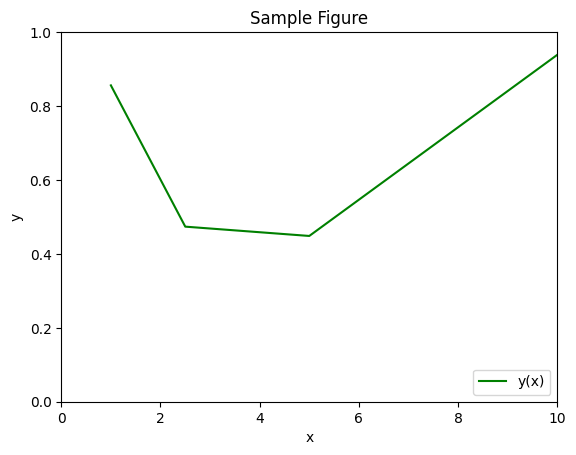

In [6]:
plt.figure()

plt.plot(x,y, 'g', label='y(x)')

plt.legend(loc='lower right')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sample Figure')
plt.xlim([0, 10])
plt.ylim([0, 1])
plt.savefig('img/sample.png')
plt.show()

## Matrices

Matrices are simply 2D arrays. Since vectors and matrices share the same type, the notion of *shape* is very important.

In [7]:
M = np.array([[0.25, 6.2, 1, 10],[12, 6.2, 6, -5.3]])
print(M,type(M))

[[ 0.25  6.2   1.   10.  ]
 [12.    6.2   6.   -5.3 ]] <class 'numpy.ndarray'>


In [8]:
print(x,type(x))

[ 1.   2.5  5.  10. ] <class 'numpy.ndarray'>


* The `size` of an array is the number of elements while the `shape` gives how they are arranged.

In [9]:
print(x.size)  # or equivalently np.size(x)
print(M.size)

4
8


In [10]:
print(x.shape)  # or equivalently np.shape(x)
print(M.shape)

(4,)
(2, 4)


* The element access, assignment, type, copy is common and similar to the list type.

In [11]:
print(x)
print(x[2],x[-1])
print(x[::-1])
x[0] = 6.1554
print(x)

[ 1.   2.5  5.  10. ]
5.0 10.0
[10.   5.   2.5  1. ]
[ 6.1554  2.5     5.     10.    ]


In [12]:
v = x
w = np.copy(x)
print(v)
x[0]=1
print(v)
print(w)

[ 6.1554  2.5     5.     10.    ]
[ 1.   2.5  5.  10. ]
[ 6.1554  2.5     5.     10.    ]


In [13]:
print(M)
print(M[1,2],type(M[1,2]))
print(M[1,:],type(M[1,:]),M[1,:].shape)
print(M[1])
print(M[:,0])

[[ 0.25  6.2   1.   10.  ]
 [12.    6.2   6.   -5.3 ]]
6.0 <class 'numpy.float64'>
[12.   6.2  6.  -5.3] <class 'numpy.ndarray'> (4,)
[12.   6.2  6.  -5.3]
[ 0.25 12.  ]


Advanced access to content and modification is possible

In [14]:
x = np.array([1, 2.5, 5, 10])
ind = [0,2,3]
print(x[ind])

[ 1.  5. 10.]


### Advanced array properties [*]


An array has a *type* that can be accessed with <tt>dtype</tt>, it the combination of a base type (<tt>int, float, complex, bool, object,</tt> etc.) and a precision in bits (<tt>int64, int16, float128, complex128</tt>)

In [15]:
print(x.dtype)

float64


Array only accept they casting to their own type. However, the type of an array can be changed.

In [16]:
try:
    x[0] = 1 + 2.0j
except Exception as e:
    print(e)

float() argument must be a string or a real number, not 'complex'


In [17]:
y = x.astype(complex)
y[0] = 1 + 2.0j
print(y,type(y),y.dtype)

[ 1. +2.j  2.5+0.j  5. +0.j 10. +0.j] <class 'numpy.ndarray'> complex128


## Numpy array generation

See the corresponding [documentation](https://numpy.org/doc/stable/user/basics.creation.html)

### Number sequences


`arange` returns an array of evenly spaced number from `start` to (at most) `stop` with a fixed jump `step`


`linspace` returns an array of evenly spaced number from `start` to (exactly) `stop` with a fixed number of points `num`

In [18]:
x = np.arange(0, 10, 1.5)
print(x,type(x))

[0.  1.5 3.  4.5 6.  7.5 9. ] <class 'numpy.ndarray'>


In [19]:
y = np.linspace(0, 10, 25)
print(y,type(y))

[ 0.          0.41666667  0.83333333  1.25        1.66666667  2.08333333
  2.5         2.91666667  3.33333333  3.75        4.16666667  4.58333333
  5.          5.41666667  5.83333333  6.25        6.66666667  7.08333333
  7.5         7.91666667  8.33333333  8.75        9.16666667  9.58333333
 10.        ] <class 'numpy.ndarray'>


### Zeros and Ones


`zeros` returns an array (of floats) of zeros  of the precised `shape`

`ones`  returns an array (of floats) of ones  of the precised `shape`

`eye`  returns a square 2D-array (of floats) with ones on the diagonal and zeros elsewhere  

In [20]:
x = np.zeros(3)
print(x,x.shape,type(x),x.dtype)

x = np.zeros((3,))
print(x,x.shape,type(x),x.dtype)

[0. 0. 0.] (3,) <class 'numpy.ndarray'> float64
[0. 0. 0.] (3,) <class 'numpy.ndarray'> float64


In [21]:
try:
    x = np.zeros(3,3) # This causes an error as 3,3 is not a shape, it is (3,3) -> double parentheses
except Exception as error:
    print(error)

print(x,x.shape,type(x),x.dtype)

Cannot interpret '3' as a data type
[0. 0. 0.] (3,) <class 'numpy.ndarray'> float64


In [22]:
x = np.zeros((3,3))
print(x,x.shape,type(x),x.dtype)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]] (3, 3) <class 'numpy.ndarray'> float64


In [23]:
y = np.ones(2)
y

array([1., 1.])

In [24]:
M = np.eye(3)
print(M,M.shape,type(M),M.dtype)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]] (3, 3) <class 'numpy.ndarray'> float64


### Random data


Random arrays can be generated by Numpy's [random](https://numpy.org/doc/stable/reference/random/index.html) module.


`rand` returns an array (of floats) of uniformly distributed numbers in [0,1)  of the precised dimension

`randn`  returns an array (of floats) of numbers from the normal distribution of the precised dimension

`randint`  returns an array (of floats) of integers from the discrete uniform distribution

In [25]:
np.random.rand(5)

array([0.6199858 , 0.15070974, 0.99504046, 0.83611838, 0.99046794])

In [26]:
np.random.randn(5,2)

array([[-0.86476468,  1.84122068],
       [-0.09101573,  0.43242767],
       [ 0.05444294,  0.51409661],
       [-0.44627145,  1.4973596 ],
       [-0.33089328,  1.42377226]])

In [27]:
np.random.randint(0,100,size=(10,))

array([35, 49, 24, 53, 34, 65, 45, 59, 95, 45], dtype=int32)

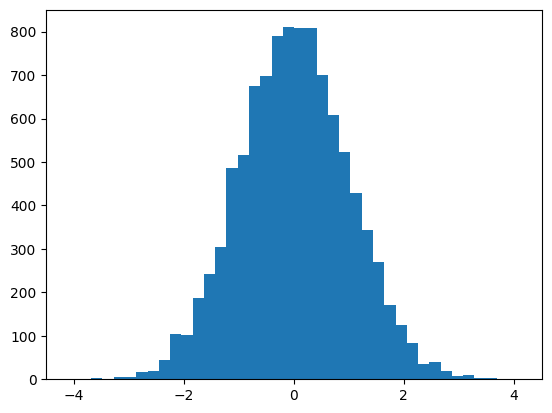

In [28]:
a = np.random.randn(10000)
plt.figure()
plt.hist(a,40) # histogram of a with 40 bins
plt.show()

## Operations on Matrices and vectors


In [29]:
v = np.arange(0, 5)
print(v)

[0 1 2 3 4]


In [30]:
v * 2

array([0, 2, 4, 6, 8])

In [31]:
v + 2.5

array([2.5, 3.5, 4.5, 5.5, 6.5])

In [32]:
square = v**2
root = np.sqrt(v)
print(square,root)

[ 0  1  4  9 16] [0.         1.         1.41421356 1.73205081 2.        ]


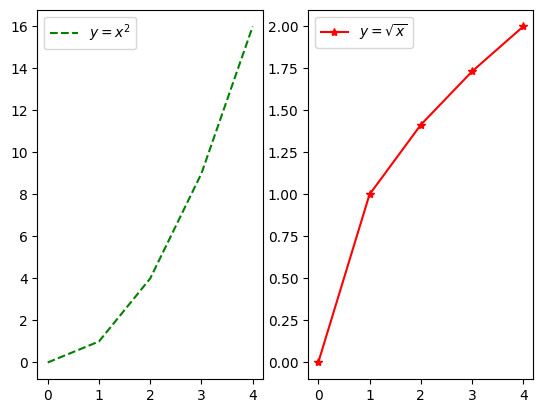

In [33]:
plt.figure()
plt.subplot(1,2,1)
plt.plot(square,'g--', label='$y = x^2$')
plt.legend(loc=0)
plt.subplot(1,2,2)
plt.plot(root, 'r*-', label='$y = \sqrt{x}$')
plt.legend(loc=2)
plt.show()

In [34]:
A = np.array([[n+m*10 for n in range(5)] for m in range(4)])
print(A)

[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]]


In [35]:
A*2

array([[ 0,  2,  4,  6,  8],
       [20, 22, 24, 26, 28],
       [40, 42, 44, 46, 48],
       [60, 62, 64, 66, 68]])

In [36]:
A+2.5

array([[ 2.5,  3.5,  4.5,  5.5,  6.5],
       [12.5, 13.5, 14.5, 15.5, 16.5],
       [22.5, 23.5, 24.5, 25.5, 26.5],
       [32.5, 33.5, 34.5, 35.5, 36.5]])

Matrices can be visualized as images.

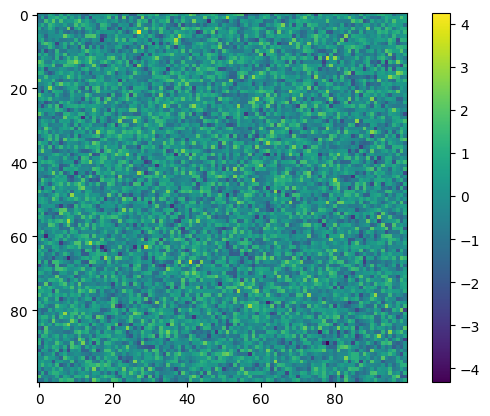

In [37]:
C = np.random.randn(100,100)
plt.figure()
plt.imshow(C)
plt.colorbar()
plt.show()

## Matrix and vector operations



*Warning:* Operation symbols `+   -   *  /` correspond to *elementwise* operations! To perform, matrix/vector multiplication, dedicated function must be used.

### Elementwise operations

In [38]:
A = np.array([[n+m*10 for n in range(5)] for m in range(4)])
v = np.random.randint(0,5,5)
print(A,v)

[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]] [0 3 4 0 4]


In [39]:
A*A

array([[   0,    1,    4,    9,   16],
       [ 100,  121,  144,  169,  196],
       [ 400,  441,  484,  529,  576],
       [ 900,  961, 1024, 1089, 1156]])

In [40]:
v*v

array([ 0,  9, 16,  0, 16], dtype=int32)

In [41]:
A*v

array([[  0,   3,   8,   0,  16],
       [  0,  33,  48,   0,  56],
       [  0,  63,  88,   0,  96],
       [  0,  93, 128,   0, 136]])

### Transposition

It can be useful to transpose, it is simply done by suffixing `.T` (or equivalently using the function `np.transpose`). Similarly `.H` is the Hermitian conjugate,  `.imag`  `.real` are the real and imaginary parts and  `.abs` the modulus (their *full* versions are respectively `np.conjugate`, `np.imag`, etc.)

In [42]:
print(A,A.shape)
print(A.T,A.T.shape)

[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]] (4, 5)
[[ 0 10 20 30]
 [ 1 11 21 31]
 [ 2 12 22 32]
 [ 3 13 23 33]
 [ 4 14 24 34]] (5, 4)


### Matrix/vector operations

$y=Av$ can be obtained by `y = A.dot(v)` (or equivalently `y = np.dot(A,v)`). This methods works for array with *compatible shape* (matrix-matrix, matrix-vector, vector-matrix, vector-vector, etc).


In [43]:
y = np.dot(A,v)
print(A,A.shape,v,v.shape)
print(y,type(y),y.shape)

[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]] (4, 5) [0 3 4 0 4] (5,)
[ 27 137 247 357] <class 'numpy.ndarray'> (4,)


Example of vector-vector multiplication i.e. a scalar product

In [44]:
s = v.dot(v)
print(v, s, type(s))

[0 3 4 0 4] 41 <class 'numpy.int32'>


Example of non-compatible shapes

In [45]:
try:
    A2 = np.dot(A,A)
except Exception as error:
    print(error)

shapes (4,5) and (4,5) not aligned: 5 (dim 1) != 4 (dim 0)


In [46]:
A3 = np.dot(A,A.T)
print(A3,A3.shape)

[[  30  130  230  330]
 [ 130  730 1330 1930]
 [ 230 1330 2430 3530]
 [ 330 1930 3530 5130]] (4, 4)


From a vector $v$, one can form the matrix $P=v v^T$ by `A=v.outer(v)` (or equivalently `np.outer(v,v)`)

In [47]:
P = np.outer(v,v)
print(P)

[[ 0  0  0  0  0]
 [ 0  9 12  0 12]
 [ 0 12 16  0 16]
 [ 0  0  0  0  0]
 [ 0 12 16  0 16]]


### Useful Functions

See the Documentation on [arrays](https://numpy.org/doc/stable/reference/arrays.ndarray.html)  and  [array creation](https://numpy.org/doc/stable/reference/routines.array-creation.html).

*Warning:* Modificators such as transpose, reshape, etc. do not modify the matrix, if you want to keep the result of the operation, you have to assign a variable to it. The notable exceptions are precised as *in-place* in the documentation.

In [48]:
A.reshape((2,10))

array([[ 0,  1,  2,  3,  4, 10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24, 30, 31, 32, 33, 34]])

In [49]:
print(A)

[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]]


In [50]:
B = A.flatten()
print(B)

[ 0  1  2  3  4 10 11 12 13 14 20 21 22 23 24 30 31 32 33 34]


In [51]:
print(A.trace(),A.max(),A.argmax())

66 34 19


Some functions may be taken with respects to the columns with <tt>axis=0</tt> or lines with <tt>axis=1</tt>.

In [52]:
print(A.mean(),A.mean(axis=0),A.mean(axis=1))

17.0 [15. 16. 17. 18. 19.] [ 2. 12. 22. 32.]


In [53]:
print(A.var(),A.var(axis=0),A.std(axis=1))

127.0 [125. 125. 125. 125. 125.] [1.41421356 1.41421356 1.41421356 1.41421356]


### Repetition, concatenation

In [54]:
a = np.array([[1, 2], [3, 4]])
a

array([[1, 2],
       [3, 4]])

In [55]:
b = np.array([[5, 6]])
b

array([[5, 6]])

In [56]:
np.concatenate((a, b), axis=0)

array([[1, 2],
       [3, 4],
       [5, 6]])

In [57]:
np.concatenate((a, b.T), axis=1)

array([[1, 2, 5],
       [3, 4, 6]])

In [58]:
np.vstack((a,b))

array([[1, 2],
       [3, 4],
       [5, 6]])

In [59]:
np.hstack((a,b.T))

array([[1, 2, 5],
       [3, 4, 6]])

### Iterating on arrays

In [60]:
v = np.array([1,2,3,4])

for element in v:
    print(element)

1
2
3
4


In [61]:
a = np.array([[1,2], [3,4]])

for row in a:
    print("row", row)

    for element in row:
        print(element)

row [1 2]
1
2
row [3 4]
3
4


<tt>enumerate</tt> can be used to get indexes along with elements.

In [62]:
for row_idx, row in enumerate(a):
    print("row_idx", row_idx, "row", row)

    for col_idx, element in enumerate(row):
        print("col_idx", col_idx, "element", element)

        # update the matrix a: square each element
        a[row_idx, col_idx] = element ** 2

row_idx 0 row [1 2]
col_idx 0 element 1
col_idx 1 element 2
row_idx 1 row [3 4]
col_idx 0 element 3
col_idx 1 element 4


In [63]:
a

array([[ 1,  4],
       [ 9, 16]])

# 3- Linear Algebra


Numpy comes with an efficient linear algebra module named `linalg` (see the [documentation](https://numpy.org/doc/stable/reference/routines.linalg.html) ). As in many languages, the more vectorized the operations are, the more efficient.

## Decompositions


* *QR:* `linalg.qr` Factor the matrix $A$ as $QR$, where $Q$ is orthonormal and $R$ is upper-triangular.
* *Cholesky:* `linalg.cholesky` Return the Cholesky decomposition, $L L^H$, of the square matrix $A$, where $L$ is lower-triangular. $A$ must be Hermitian and positive-definite. Only $L$ is actually returned.
* *SVD:* `linalg.svd`  Factors the matrix $A$ as $U  \text{diag}(s) V$, where $U$ and $V$ are unitary and $s$ is a 1-d array of $A$‘s singular values.



In [64]:
A = np.random.randn(3,2)

In [65]:
Q, R = np.linalg.qr(A)
print(A)
print(Q)
print(R)

[[-1.5743663   0.90951442]
 [-0.57453111  0.66056988]
 [ 0.09492487  1.03752   ]]
[[-0.93789972  0.04174074]
 [-0.34226632 -0.27316839]
 [ 0.05654975 -0.96106022]]
[[ 1.67860834 -1.02045265]
 [ 0.         -1.1396022 ]]


In [66]:
np.allclose(A, np.dot(Q, R)) # check that A=QR

True

In [67]:
U, s, V = np.linalg.svd(A)
print(U.shape, V.shape, s.shape)

(3, 3) (2, 2) (2,)


In [68]:
S = np.zeros(A.shape)
S[:A.shape[1], :A.shape[1]] = np.diag(s)
np.allclose(A, np.dot(U, np.dot(S, V)))

True

By default, $U$ and $V$ have the shapes $(M, M)$ and $(N, N)$  respectively if $A$ is $(M,N)$. If `full_matrices=False` is passed, the shapes are $(M, K)$ and $(K, N)$, respectively, where $K = min(M, N)$.

In [69]:
U, s, V = np.linalg.svd(A, full_matrices=False)
print(U.shape, V.shape, s.shape)

(3, 2) (2, 2) (2,)


In [70]:
S = np.diag(s)
np.allclose(A, np.dot(U, np.dot(S, V)))

True

## Eigenvalues

`linalg.eig` compute the eigenvalues and right eigenvectors of a square array and is the main function (`linalg.eigvals` computes eigenvalues of a non-symmetric array, `linalg.eigh` returns eigenvalues and eigenvectors of a symmetric or Hermitian array).

In [71]:
A = np.array([[1, -1], [1, 1]])
print(A)
l, v = np.linalg.eig(A)
print(l); print(v)

[[ 1 -1]
 [ 1  1]]
[1.+1.j 1.-1.j]
[[0.70710678+0.j         0.70710678-0.j        ]
 [0.        -0.70710678j 0.        +0.70710678j]]


In [72]:
A.dot(v[:,0])

array([0.70710678+0.70710678j, 0.70710678-0.70710678j])

We can check that $Ax= \lambda x$.

In [73]:
np.allclose(A.dot(v[:,0]),l[0]*v[:,0])

True

## Norms and other numbers

The function `linalg.norm` is able to return one of eight different matrix norms, or one of an infinite number of vector norms (described below), depending on the value of the `ord` parameter.

<table border="1" class="docutils">
<colgroup>
<col width="8%" />
<col width="47%" />
<col width="44%" />
</colgroup>
<thead valign="bottom">
<tr class="row-odd"><th class="head">ord</th>
<th class="head">norm for matrices</th>
<th class="head">norm for vectors</th>
</tr>
</thead>
<tbody valign="top">
<tr class="row-even"><td>None</td>
<td>Frobenius norm</td>
<td>2-norm</td>
</tr>
<tr class="row-odd"><td>&#8216;fro&#8217;</td>
<td>Frobenius norm</td>
<td>&#8211;</td>
</tr>
<tr class="row-even"><td>&#8216;nuc&#8217;</td>
<td>nuclear norm</td>
<td>&#8211;</td>
</tr>
<tr class="row-odd"><td>inf</td>
<td>max(sum(abs(x), axis=1))</td>
<td>max(abs(x))</td>
</tr>
<tr class="row-even"><td>-inf</td>
<td>min(sum(abs(x), axis=1))</td>
<td>min(abs(x))</td>
</tr>
<tr class="row-odd"><td>0</td>
<td>&#8211;</td>
<td>sum(x != 0)</td>
</tr>
<tr class="row-even"><td>1</td>
<td>max(sum(abs(x), axis=0))</td>
<td>as below</td>
</tr>
<tr class="row-odd"><td>-1</td>
<td>min(sum(abs(x), axis=0))</td>
<td>as below</td>
</tr>
<tr class="row-even"><td>2</td>
<td>2-norm (largest sing. value)</td>
<td>as below</td>
</tr>
<tr class="row-odd"><td>-2</td>
<td>smallest singular value</td>
<td>as below</td>
</tr>
<tr class="row-even"><td>other</td>
<td>&#8211;</td>
<td>sum(abs(x)$^{ord}$)$^{(1./ord)}$</td>
</tr>
</tbody>
</table>

In [74]:
a = np.arange(9) - 4
B = a.reshape((3, 3))

In [75]:
print(a)
print("none \t",np.linalg.norm(a))
print("2 \t",np.linalg.norm(a,ord=2))
print("1 \t",np.linalg.norm(a,ord=1))
print("inf \t",np.linalg.norm(a,ord=np.inf))
print("0 \t",np.linalg.norm(a,ord=0))

[-4 -3 -2 -1  0  1  2  3  4]
none 	 7.745966692414834
2 	 7.745966692414834
1 	 20.0
inf 	 4.0
0 	 8.0


In [76]:
print(B)
print("none \t",np.linalg.norm(B))
print("2 \t",np.linalg.norm(B,ord=2))
print("1 \t",np.linalg.norm(B,ord=1))
print("inf \t",np.linalg.norm(B,ord=np.inf))
print("fro \t",np.linalg.norm(B,ord='fro'))

[[-4 -3 -2]
 [-1  0  1]
 [ 2  3  4]]
none 	 7.745966692414834
2 	 7.348469228349534
1 	 7.0
inf 	 9.0
fro 	 7.745966692414834


Other useful function include the condition number `linalg.cond`, or rank `linalg.matrix_rank` .

In [77]:
A = np.array([[1, 0, -1], [0, 1, 0], [1, 0, 1]]) # some matrix
I = np.eye(4) # identity
Def =  np.eye(4); Def[0,0]=0 # rank deficient

In [78]:
print(np.linalg.cond(A), np.linalg.cond(I))

1.4142135623730951 1.0


In [79]:
np.linalg.cond(Def)

np.float64(inf)

In [80]:
print(np.linalg.matrix_rank(A), np.linalg.matrix_rank(I), np.linalg.matrix_rank(Def))

3 4 3


#Practice Tasks

In [91]:
#Create a NumPy array of integers from 1 to 10.

#Use the .reshape() method to change the shape of the array to a 2x5 matrix.
import numpy as np

arr = np.arange(1, 11)
matrix = arr.reshape(2, 5)

print(matrix)

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]]


In [92]:
#Create a 5x5 NumPy array filled with random integers between 1 and 100.

#Extract the middle 3x3 section of the array using slicing.
import numpy as np

arr = np.random.randint(1, 101, size=(5, 5))

print("Original Array:")
print(arr)

middle = arr[1:4, 1:4]

print("\nMiddle 3x3 Section:")
print(middle)

Original Array:
[[49 40 48 31 97]
 [78 83 53 88 59]
 [68  9 57 96 88]
 [12 43 46 52 96]
 [87 70 47 90 12]]

Middle 3x3 Section:
[[83 53 88]
 [ 9 57 96]
 [43 46 52]]


In [93]:
#Given two arrays: a = np.array([1, 2, 3, 4, 5]) and b = np.array([6, 7, 8, 9, 10]), compute the element-wise sum, difference, product, and division of a and b.
import numpy as np

a = np.array([1, 2, 3, 4, 5])
b = np.array([6, 7, 8, 9, 10])

print("Sum:", a + b)
print("Difference:", a - b)
print("Product:", a * b)
print("Division:", a / b)

Sum: [ 7  9 11 13 15]
Difference: [-5 -5 -5 -5 -5]
Product: [ 6 14 24 36 50]
Division: [0.16666667 0.28571429 0.375      0.44444444 0.5       ]


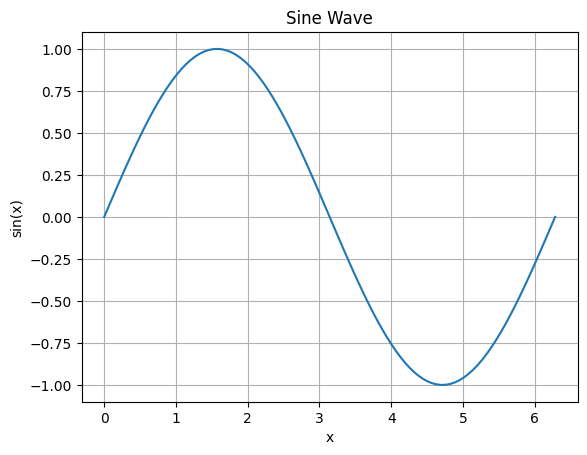

In [94]:
#Plot the sine wave for x values ranging from 0 to 2*pi. Use 100 points and display the plot with appropriate labels for the x and y axes.
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.title("Sine Wave")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True)
plt.show()


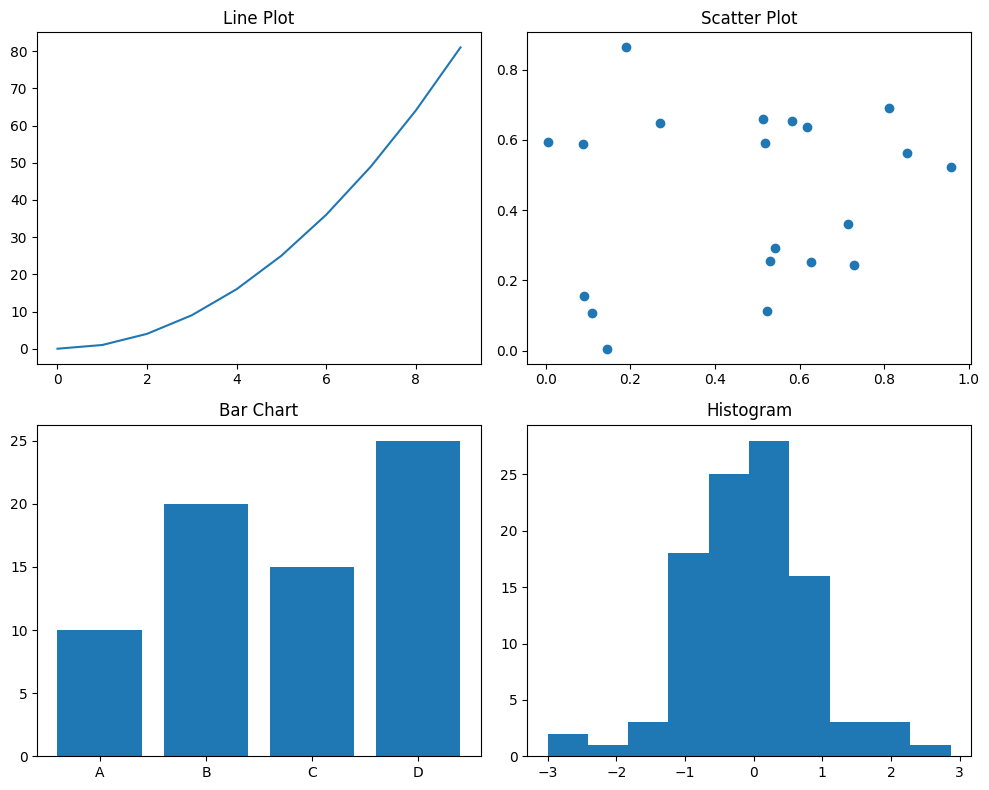

In [95]:
#Create a 2x2 subplot layout in Matplotlib and display the following in each subplot:

#A line plot of y = x^2.

#A scatter plot of random points.

#A bar chart of some arbitrary data.

#A histogram of random numbers.
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# Line Plot
x = np.arange(10)
ax[0, 0].plot(x, x**2)
ax[0, 0].set_title("Line Plot")

# Scatter Plot
ax[0, 1].scatter(np.random.rand(20), np.random.rand(20))
ax[0, 1].set_title("Scatter Plot")

# Bar Chart
categories = ['A', 'B', 'C', 'D']
values = [10, 20, 15, 25]
ax[1, 0].bar(categories, values)
ax[1, 0].set_title("Bar Chart")

# Histogram
data = np.random.randn(100)
ax[1, 1].hist(data, bins=10)
ax[1, 1].set_title("Histogram")

plt.tight_layout()
plt.show()

In [96]:
#Create a NumPy array of 50 random numbers. Use np.mean(), np.median(), and np.std() to compute the mean, median, and standard deviation of the array.
import numpy as np

arr = np.random.rand(50)

print("Mean:", np.mean(arr))
print("Median:", np.median(arr))
print("Standard Deviation:", np.std(arr))

Mean: 0.5024063121787897
Median: 0.4759992766595673
Standard Deviation: 0.29729051806472


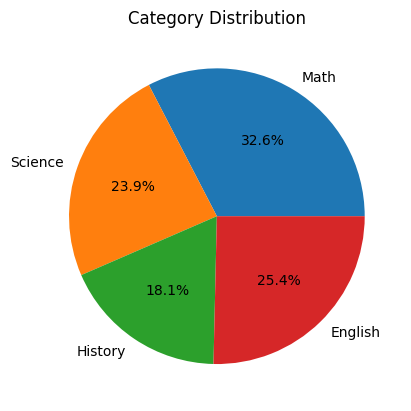

In [97]:
#Plot a pie chart showing the distribution of data in a given list of categories, e.g., ['Math', 'Science', 'History', 'English'], with random values for each category.
import numpy as np
import matplotlib.pyplot as plt

categories = ['Math', 'Science', 'History', 'English']
values = np.random.randint(10, 50, size=4)

plt.pie(values, labels=categories, autopct='%1.1f%%')
plt.title("Category Distribution")
plt.show()

In [98]:
#Create a 3x3 matrix filled with random integers between 1 and 10.

#Transpose the matrix and then find the sum of each column.
import numpy as np

matrix = np.random.randint(1, 11, size=(3, 3))

print("Original Matrix:")
print(matrix)

transpose = matrix.T
print("\nTranspose:")
print(transpose)

column_sum = np.sum(matrix, axis=0)
print("\nColumn Sums:")
print(column_sum)


Original Matrix:
[[4 2 5]
 [5 6 2]
 [4 7 7]]

Transpose:
[[4 5 4]
 [2 6 7]
 [5 2 7]]

Column Sums:
[13 15 14]


In [99]:
#Write a function that takes a NumPy array and returns the array after squaring all the elements.
import numpy as np

def square_array(arr):
    return arr ** 2

arr = np.array([1, 2, 3, 4, 5])

print("Original Array:", arr)
print("Squared Array:", square_array(arr))

Original Array: [1 2 3 4 5]
Squared Array: [ 1  4  9 16 25]


In [100]:
#Create a 5x5 NumPy array with random values and introduce some NaN (Not a Number) values.

#Use NumPy functions to fill in the NaN values with the column mean of the array.
import numpy as np

arr = np.random.rand(5, 5)

arr[1, 2] = np.nan
arr[3, 4] = np.nan

print("Original Array:")
print(arr)

col_mean = np.nanmean(arr, axis=0)

inds = np.where(np.isnan(arr))
arr[inds] = np.take(col_mean, inds[1])

print("\nArray after replacing NaN with column mean:")
print(arr)

Original Array:
[[0.36425389 0.7030174  0.00510809 0.74664921 0.09286797]
 [0.80479315 0.84144728        nan 0.59238541 0.46486006]
 [0.41929318 0.08294038 0.31530799 0.8124454  0.99327028]
 [0.73488637 0.86174688 0.45920533 0.77786598        nan]
 [0.51266674 0.19087282 0.26915558 0.83334206 0.6476629 ]]

Array after replacing NaN with column mean:
[[0.36425389 0.7030174  0.00510809 0.74664921 0.09286797]
 [0.80479315 0.84144728 0.26219425 0.59238541 0.46486006]
 [0.41929318 0.08294038 0.31530799 0.8124454  0.99327028]
 [0.73488637 0.86174688 0.45920533 0.77786598 0.5496653 ]
 [0.51266674 0.19087282 0.26915558 0.83334206 0.6476629 ]]
